# Korpusanalyse: Rohdaten vs. Normalisierung & Bereinigung (Master-Korpus)

### Ziel dieser Auswertung:


In [1]:
import os, sys

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, 'data')) and os.path.exists(os.path.join(p, 'results')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser('~/Documents/Master Thesis'))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
import os
import sys
import glob
import json
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken
from tqdm.auto import tqdm
from IPython.display import display

while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text: str) -> int:
    return len(enc.encode(text)) if text else 0

def count_sentences(text: str) -> int:
    if not text:
        return 0
    sentences = re.split(r'[.!?](?:\s+|$)|(?:\n\s*\n)', text)
    return len([s for s in sentences if s.strip()])

def tokenize_words(text: str) -> list:
    return re.findall(r'[\w∙·-]+', text.lower())

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
palette_stages = ["#e74c3c", "#2ecc71"]


Aktuelles Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 1. Definition der Boilerplate- & Bias-Kategorien

7. **Listen- und Bullet-Point-Artefakte**: `•`, `*`, `: •`, `: ,`.

8. **Doppelte Satzzeichen**: `..`, `...`, `: ..`, `; ..`, `..;`.

9. **Mediopunkte / Silbentrennung**: `·`, `∙`.


In [2]:
boilerplate_categories = {
    "1. Navigation & Links": [
        r"mehr informationen", r"mehr infos", r"weitere informationen", r"auf dieser seite",
        r"im internet unter", r"hier finden sie", r"hier gibt es", r"klicken sie", r"tippen sie",
        r"hier erfahren sie", r"hier lesen sie", r"hier kommen sie", r"hier geht es zu",
        r"sprechen sie uns an", r"in alltagssprache", r"\(alltagssprache\)", r"einen link",
        r"links?\s+(link\s+)?(zum|zur|zu|unter)", r"dann finden sie in dieser tabelle",
        r"https?://", r"\(abgerufen am"
    ],
    "2. Frageketten & Tools": [
        r"wo (finde|bekomme) ich", r"wo bekommen sie", r"wie kann ich", r"sie möchten",
        r"sie wollen noch mehr", r"sie interessieren sich für", r"unser tool durchsucht",
        r"welche frage zu", r"ihre frage wird nicht gespeichert"
    ],
    "3. Disclaimer & Warnungen": [
        r"dieser link führt", r"aus unserem einfache-sprache-angebot", r"nicht mehr in (einfacher|leichter) sprache",
        r"achtung:\s*dieser link", r"achtung:\s*in diesem text", r"allgemeine informationen.*arztpraxis",
        r"heilpflanzen gegen ihre beschwerden"
    ],
    "4. Credits & Prüfstellen": [
        r"forschungsstelle leichte sprache", r"universität hildesheim", r"stefan albers",
        r"atelier fleetinsel", r"european easy-to-read logo", r"inclusion europe",
        r"geprüft von", r"übersetzt von", r"institut für leichte sprache",
        r"übertragung in leichte sprache", r"büro für leichte sprache", r"haben den text geprüft",
        r"haben den text geschrieben und gelesen", r"hat die bilder gemalt", r"die bilder im text sind von",
        r"die bilder gehören:", r"über dieses thema berichtet der mdr auch"
    ],
    "5. Kicker & Dachzeilen": [
        r"^(sachsen-anhalt|sachsen|thüringen|mittel-deutschland|mitteldeutschland)\b",
        r"in leichter sprache ticker", r"^glossar\s*:"
    ],
    "6. Regionale & Bild-Artefakte": [
        r"icon für die mobilversion", r"fotografiert von", r"infobus", r"das team vom",
        r"regionspräsident steffen krach", r"von der .*straße aus fotografiert", r"mehr anzeigen"
    ]
}

def detect_boilerplate(text: str) -> dict:
    res = {}
    if not text:
        for cat in boilerplate_categories:
            res[cat] = False
        res["has_bullets"] = False
        res["has_double_punct"] = False
        res["has_mediopunkt"] = False
        res["has_any_boilerplate"] = False
        return res
        
    text_lower = text.lower()
    for cat, patterns in boilerplate_categories.items():
        res[cat] = any(re.search(p, text_lower) for p in patterns)
    
    res["has_bullets"] = bool(re.search(r'(•|\*|:\s*•)', text))
    res["has_double_punct"] = bool(re.search(r'(\.\.{2,}|:\s*\.+|;\s*\.+|\.\s*;\s*)', text))
    res["has_mediopunkt"] = ("·" in text) or ("∙" in text)
    res["has_any_boilerplate"] = (
        any(res[cat] for cat in boilerplate_categories) or 
        res["has_bullets"] or 
        res["has_double_punct"] or 
        res["has_mediopunkt"]
    )
    return res


## 2. Korpuslader (Synchroner Import beider Pipeline-Stufen)


In [3]:
stages_config = [
    ("1_raw", "data/corpus/2_raw_scraped", "1. Rohdaten"),
    ("2_clean", "data/corpus/4_normalized_clean", "2. Normalisiert & Bereinigt")
]

records = []

for stage_key, stage_dir, stage_label in stages_config:
    files = sorted(glob.glob(os.path.join(stage_dir, "*_articles.json")))
    for file_path in tqdm(files, desc=f"Lade {stage_label}"):
        source_name = os.path.basename(file_path).replace("_articles.json", "")
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            
        pairs = data.get("pairs", []) if isinstance(data, dict) else data
        
        for p_idx, pair in enumerate(pairs):
            ls_text = pair.get("ls_text", "")
            as_text = pair.get("as_text", "")
            if not as_text and "as_texts" in pair:
                raw_as = pair["as_texts"]
                as_text = "\n".join(raw_as) if isinstance(raw_as, list) else str(raw_as)
                
            ls_words = len(tokenize_words(ls_text))
            as_words = len(tokenize_words(as_text))
            ls_tokens = count_tokens(ls_text)
            as_tokens = count_tokens(as_text)
            ls_chars = len(ls_text)
            as_chars = len(as_text)
            ls_sents = count_sentences(ls_text)
            as_sents = count_sentences(as_text)
            
            word_ratio = ls_words / max(1, as_words)
            token_ratio = ls_tokens / max(1, as_tokens)
            ls_w_per_s = ls_words / max(1, ls_sents)
            as_w_per_s = as_words / max(1, as_sents)
            
            bp_ls = detect_boilerplate(ls_text)
            
            rec = {
                "stage_key": stage_key,
                "stage_label": stage_label,
                "source": source_name,
                "pair_id": f"{source_name}_{p_idx}",
                "ls_text": ls_text,
                "as_text": as_text,
                "ls_words": ls_words,
                "as_words": as_words,
                "ls_tokens": ls_tokens,
                "as_tokens": as_tokens,
                "ls_chars": ls_chars,
                "as_chars": as_chars,
                "ls_sentences": ls_sents,
                "as_sentences": as_sents,
                "word_ratio": word_ratio,
                "token_ratio": token_ratio,
                "ls_w_per_s": ls_w_per_s,
                "as_w_per_s": as_w_per_s,
                "has_bullets": bp_ls["has_bullets"],
                "has_double_punct": bp_ls["has_double_punct"],
                "has_mediopunkt": bp_ls["has_mediopunkt"],
                "has_any_boilerplate": bp_ls["has_any_boilerplate"]
            }
            for cat in boilerplate_categories:
                rec[cat] = bp_ls[cat]
                
            records.append(rec)

df_all = pd.DataFrame(records)
print(f"Gesamtzahl geladener Datensätze: {len(df_all)}")
print(df_all.groupby("stage_label").size())


Lade 1. Rohdaten:   0%|          | 0/12 [00:00<?, ?it/s]

Lade 2. Normalisiert & Bereinigt:   0%|          | 0/12 [00:00<?, ?it/s]

Gesamtzahl geladener Datensätze: 2318
stage_label
1. Rohdaten                    1458
2. Normalisiert & Bereinigt     860
dtype: int64


## 3. Pipeline-Funnel: Artikelpaare, Retention & Bereinigung


In [4]:
# Pivot-Tabelle der Artikelpaare
pivot_pairs = df_all.pivot_table(index="source", columns="stage_label", values="pair_id", aggfunc="count").fillna(0).astype(int)

# Berechne Retention & Deltas
pivot_pairs["Delta (Drop)"] = pivot_pairs["2. Normalisiert & Bereinigt"] - pivot_pairs["1. Rohdaten"]
pivot_pairs["Retention (%)"] = (pivot_pairs["2. Normalisiert & Bereinigt"] / pivot_pairs["1. Rohdaten"] * 100).round(1)

# Gesamtzeile
total_s1 = len(df_all[df_all["stage_key"] == "1_raw"])
total_s2 = len(df_all[df_all["stage_key"] == "2_clean"])

totals_row = pd.Series({
    "1. Rohdaten": total_s1,
    "2. Normalisiert & Bereinigt": total_s2,
    "Delta (Drop)": total_s2 - total_s1,
    "Retention (%)": round(total_s2 / total_s1 * 100, 1)
}, name="=== GESAMT ===")

table_funnel = pd.concat([pivot_pairs, pd.DataFrame([totals_row])])
display(table_funnel)


,1. Rohdaten,2. Normalisiert & Bereinigt,Delta (Drop),Retention (%)
apotheken,161.0,153.0,-8.0,95.0
behindertenbeauftragter,58.0,47.0,-11.0,81.0
brandeins,33.0,19.0,-14.0,57.6
hamburg,54.0,46.0,-8.0,85.2
hannover,750.0,215.0,-535.0,28.7
koeln,41.0,39.0,-2.0,95.1
main_taunus,39.0,36.0,-3.0,92.3
mdr,221.0,219.0,-2.0,99.1
sozialpolitik,15.0,13.0,-2.0,86.7
stuttgart,42.0,35.0,-7.0,83.3


### Visualisierung: Artikelpaare & Retention pro Quelle


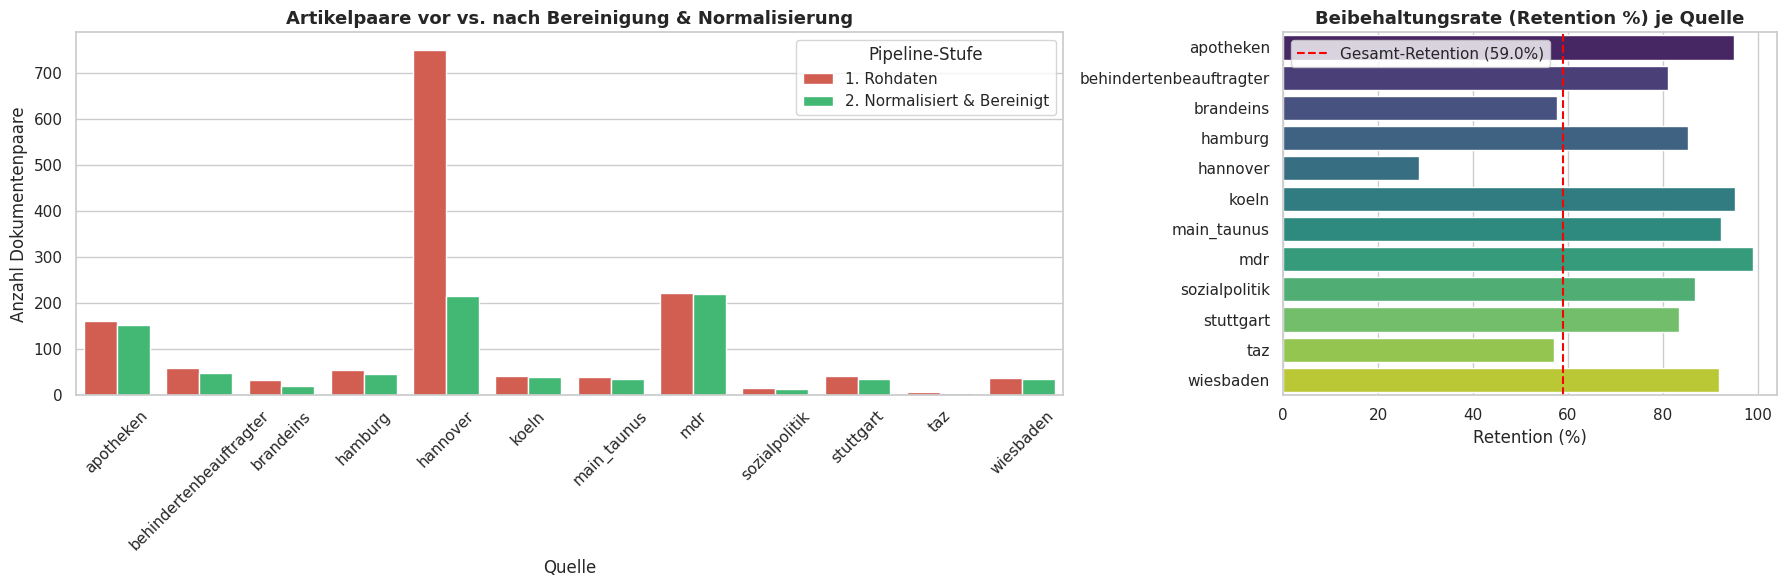

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [2, 1]})

# Plot 1: Artikelpaare pro Quelle
plot_df = pivot_pairs.reset_index()
plot_melt = pd.melt(plot_df, id_vars=["source"], value_vars=["1. Rohdaten", "2. Normalisiert & Bereinigt"], 
                    var_name="Stufe", value_name="Anzahl Paare")

sns.barplot(data=plot_melt, x="source", y="Anzahl Paare", hue="Stufe", palette=palette_stages, ax=axes[0])
axes[0].set_title("Artikelpaare vor vs. nach Bereinigung & Normalisierung", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Quelle")
axes[0].set_ylabel("Anzahl Dokumentenpaare")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Pipeline-Stufe")

# Plot 2: Retention-Rate pro Quelle
sns.barplot(data=plot_df, x="Retention (%)", y="source", hue="source", palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Beibehaltungsrate (Retention %) je Quelle", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Retention (%)")
axes[1].set_ylabel("")
ret_ges = table_funnel.loc['=== GESAMT ===', 'Retention (%)']
axes[1].axvline(ret_ges, color="red", linestyle="--", label=f"Gesamt-Retention ({ret_ges}%)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 4. Text-, Wort- und LLM-Token-Volumen


In [6]:
vol_summary = df_all.groupby(["stage_label"]).agg(
    Paare=("pair_id", "count"),
    LS_Tokens_Gesamt=("ls_tokens", "sum"),
    AS_Tokens_Gesamt=("as_tokens", "sum"),
    LS_Tokens_Mittel=("ls_tokens", "mean"),
    AS_Tokens_Mittel=("as_tokens", "mean"),
    LS_Wörter_Mittel=("ls_words", "mean"),
    AS_Wörter_Mittel=("as_words", "mean")
).round(1)

vol_summary["Tokens_Gesamt"] = vol_summary["LS_Tokens_Gesamt"] + vol_summary["AS_Tokens_Gesamt"]

print("Volumen-Metriken im Vergleich (Rohdaten vs. Bereinigt):")
display(vol_summary.T)


Volumen-Metriken im Vergleich (Rohdaten vs. Bereinigt):


stage_label,1. Rohdaten,2. Normalisiert & Bereinigt
Paare,1458.0,860.0
LS_Tokens_Gesamt,1399874.0,706724.0
AS_Tokens_Gesamt,1873830.0,1126538.0
LS_Tokens_Mittel,960.1,821.8
AS_Tokens_Mittel,1285.2,1309.9
LS_Wörter_Mittel,502.1,440.6
AS_Wörter_Mittel,591.5,606.7
Tokens_Gesamt,3273704.0,1833262.0


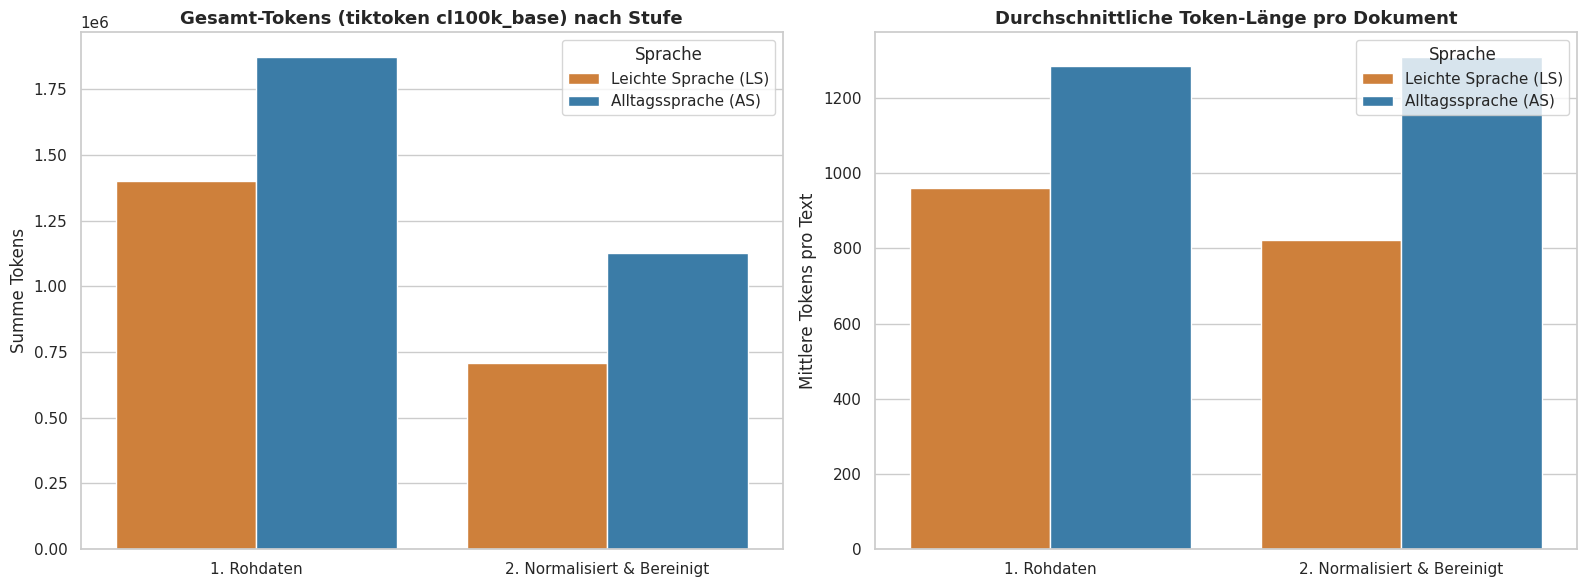

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Gesamt-Tokens
token_melt = df_all.groupby("stage_label")[["ls_tokens", "as_tokens"]].sum().reset_index()
token_melt = pd.melt(token_melt, id_vars=["stage_label"], value_vars=["ls_tokens", "as_tokens"], var_name="Sprache", value_name="Gesamt-Tokens")
token_melt["Sprache"] = token_melt["Sprache"].map({"ls_tokens": "Leichte Sprache (LS)", "as_tokens": "Alltagssprache (AS)"})

sns.barplot(data=token_melt, x="stage_label", y="Gesamt-Tokens", hue="Sprache", palette=["#e67e22", "#2980b9"], ax=axes[0])
axes[0].set_title("Gesamt-Tokens (tiktoken cl100k_base) nach Stufe", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Summe Tokens")
axes[0].set_xlabel("")

# Plot 2: Durchschnittliche Tokenlänge pro Dokument
token_mean_melt = df_all.groupby("stage_label")[["ls_tokens", "as_tokens"]].mean().reset_index()
token_mean_melt = pd.melt(token_mean_melt, id_vars=["stage_label"], value_vars=["ls_tokens", "as_tokens"], var_name="Sprache", value_name="Durchschnittliche Tokens")
token_mean_melt["Sprache"] = token_mean_melt["Sprache"].map({"ls_tokens": "Leichte Sprache (LS)", "as_tokens": "Alltagssprache (AS)"})

sns.barplot(data=token_mean_melt, x="stage_label", y="Durchschnittliche Tokens", hue="Sprache", palette=["#e67e22", "#2980b9"], ax=axes[1])
axes[1].set_title("Durchschnittliche Token-Länge pro Dokument", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Mittlere Tokens pro Text")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


## 5. Längenverhältnisse ($LS / AS$) & Ausreißer-Eliminierung


Statistiken des Wortlängen-Verhältnisses (LS / AS):


,Min,P25,Median,Mean,P75,Max,Std
stage_label,,,,,,,
1. Rohdaten,0.013,0.541,0.930,1.409,1.446,38.432,2.498
2. Normalisiert & Bereinigt,0.199,0.469,0.781,0.921,1.214,3.764,0.589


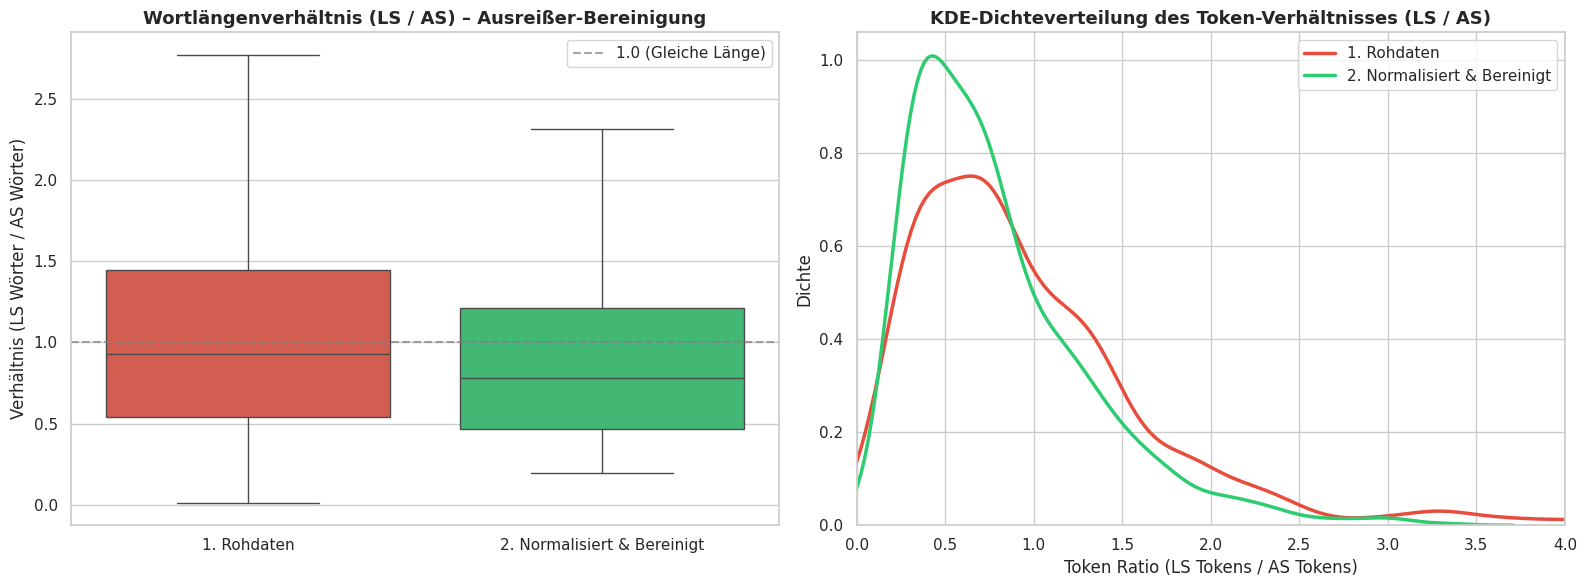

In [8]:
# Statistische Kennzahlen des Längenverhältnisses (LS Wörter / AS Wörter)
ratio_stats = df_all.groupby("stage_label")["word_ratio"].agg(
    Min="min",
    P25=lambda x: x.quantile(0.25),
    Median="median",
    Mean="mean",
    P75=lambda x: x.quantile(0.75),
    Max="max",
    Std="std"
).round(3)

print("Statistiken des Wortlängen-Verhältnisses (LS / AS):")
display(ratio_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Boxplot Längenverhältnis
sns.boxplot(data=df_all, x="stage_label", y="word_ratio", hue="stage_label", palette=palette_stages, legend=False, showfliers=False, ax=axes[0])
axes[0].set_title("Wortlängenverhältnis (LS / AS) – Ausreißer-Bereinigung", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Verhältnis (LS Wörter / AS Wörter)")
axes[0].set_xlabel("")
axes[0].axhline(1.0, color="gray", linestyle="--", alpha=0.7, label="1.0 (Gleiche Länge)")
axes[0].legend()

# Plot 2: KDE Verteilung der Token-Ratio
for stage_name, color in zip(["1. Rohdaten", "2. Normalisiert & Bereinigt"], palette_stages):
    subset = df_all[(df_all["stage_label"] == stage_name) & (df_all["token_ratio"] < 4.5)]
    sns.kdeplot(subset["token_ratio"], label=stage_name, color=color, linewidth=2.5, ax=axes[1])

axes[1].set_title("KDE-Dichteverteilung des Token-Verhältnisses (LS / AS)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Token Ratio (LS Tokens / AS Tokens)")
axes[1].set_ylabel("Dichte")
axes[1].set_xlim(0, 4.0)
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Boilerplate-Bias & Floskel-Prävalenz (Vorher vs. Nachher)


Boilerplate- und Artefakt-Prävalenz (% der Artikel):


stage_label,1. Rohdaten,2. Normalisiert & Bereinigt
1. Navigation & Links,59.95,29.30
2. Frageketten & Tools,52.19,29.65
3. Disclaimer & Warnungen,11.87,2.09
4. Credits & Prüfstellen,14.88,0.70
5. Kicker & Dachzeilen,0.14,0.00
6. Regionale & Bild-Artefakte,0.55,0.35
>>> Listen- & Bullet-Artefakte (• / *) (%),5.08,0.00
>>> Doppelte Satzzeichen (.. / : ..) (%),8.64,0.00
>>> Mediopunkte vorhanden (%),49.31,0.00
>>> GESAMT: Beliebiges Boilerplate / Artefakt (%),73.94,44.19


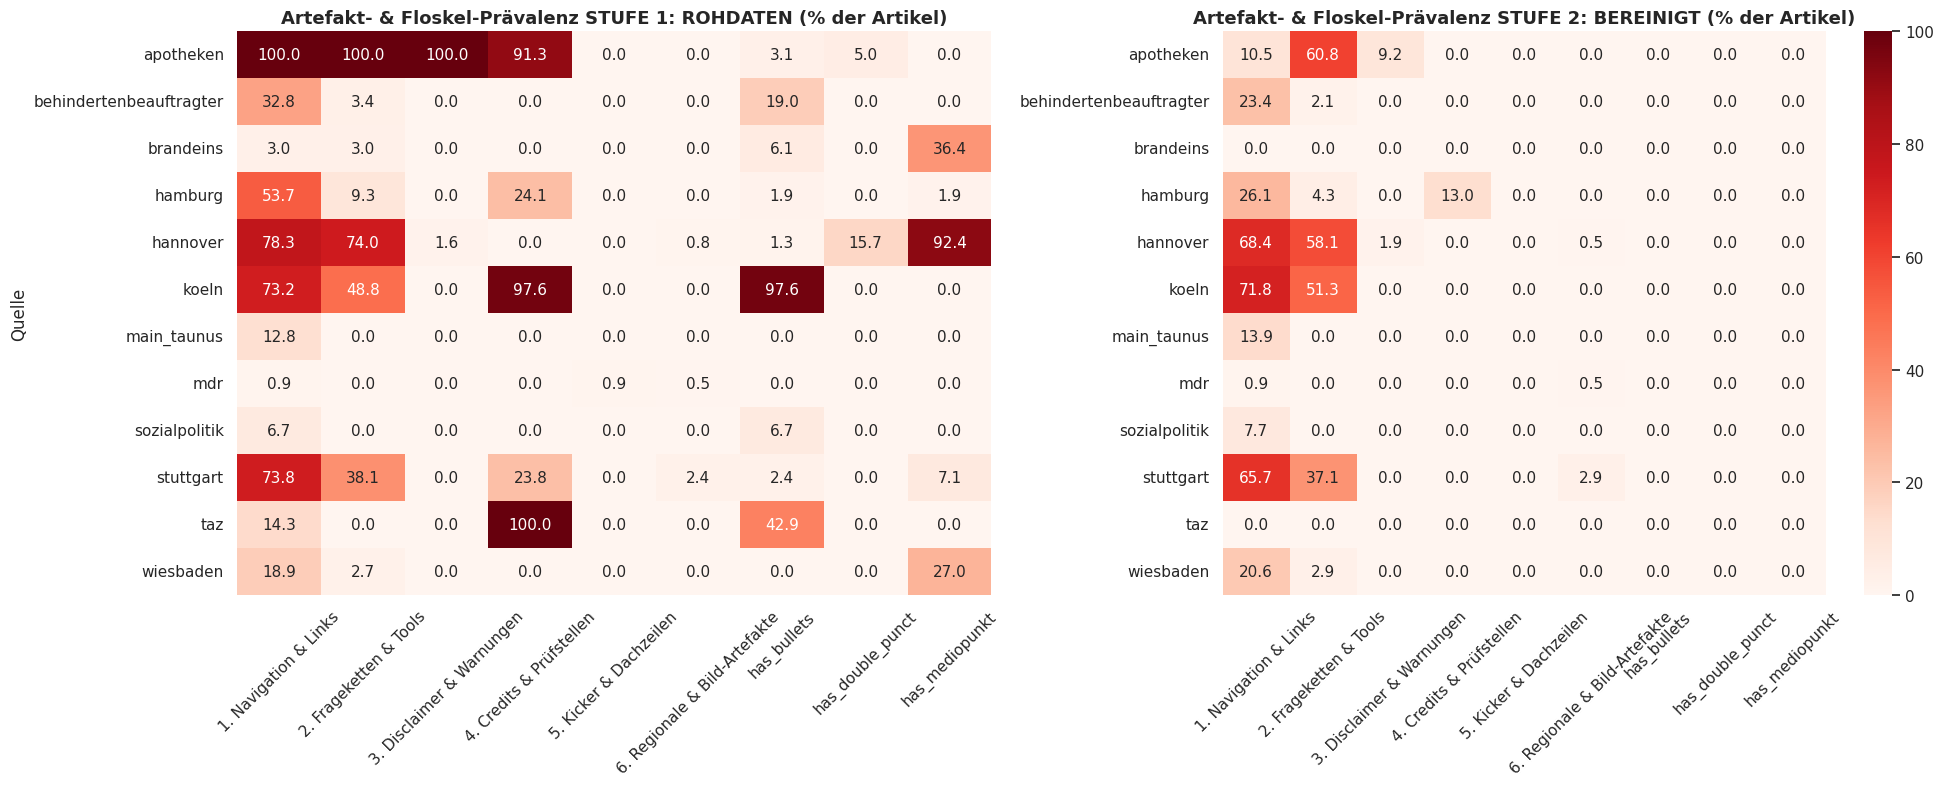

In [9]:
# Boilerplate-Prävalenz pro Stufe (in % aller Artikel)
cats = list(boilerplate_categories.keys()) + ["has_bullets", "has_double_punct", "has_mediopunkt", "has_any_boilerplate"]

bp_stage_summary = (df_all.groupby("stage_label")[cats].mean() * 100).round(2)
bp_stage_summary.rename(columns={
    "has_bullets": ">>> Listen- & Bullet-Artefakte (• / *) (%)",
    "has_double_punct": ">>> Doppelte Satzzeichen (.. / : ..) (%)",
    "has_mediopunkt": ">>> Mediopunkte vorhanden (%)",
    "has_any_boilerplate": ">>> GESAMT: Beliebiges Boilerplate / Artefakt (%)"
}, inplace=True)

print("Boilerplate- und Artefakt-Prävalenz (% der Artikel):")
display(bp_stage_summary.T)

# Heatmap-Vergleich pro Quelle: Rohdaten (Stufe 1) vs Bereinigt (Stufe 2)
raw_df = df_all[df_all["stage_key"] == "1_raw"]
clean_df = df_all[df_all["stage_key"] == "2_clean"]

heat_cols = list(boilerplate_categories.keys()) + ["has_bullets", "has_double_punct", "has_mediopunkt"]

heat_raw = raw_df.groupby("source")[heat_cols].mean() * 100
heat_clean = clean_df.groupby("source")[heat_cols].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(heat_raw, annot=True, fmt=".1f", cmap="Reds", cbar=False, ax=axes[0], vmin=0, vmax=100)
axes[0].set_title("Artefakt- & Floskel-Prävalenz STUFE 1: ROHDATEN (% der Artikel)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Quelle")
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(heat_clean, annot=True, fmt=".1f", cmap="Reds", cbar=True, ax=axes[1], vmin=0, vmax=100)
axes[1].set_title("Artefakt- & Floskel-Prävalenz STUFE 2: BEREINIGT (% der Artikel)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 7. Satzlängen ($W/S$) & Interpunktions-Integrität (LS vs. AS)


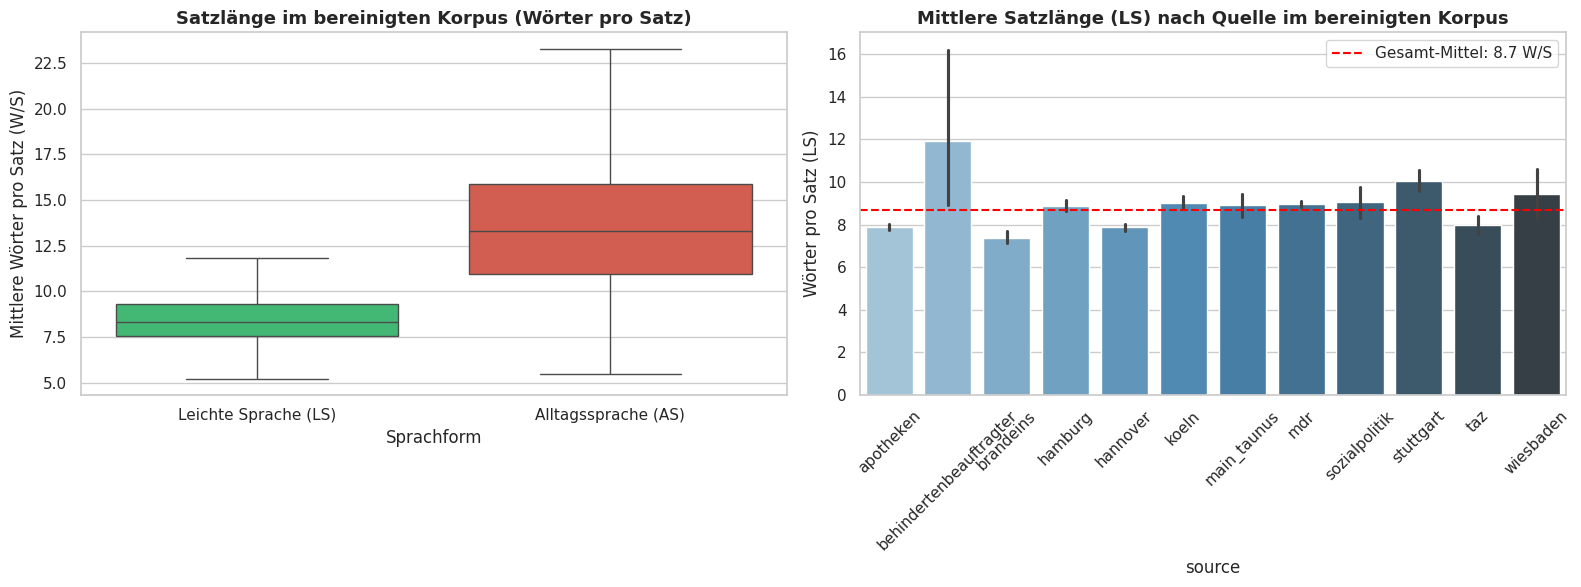

Durchschnittliche Satzlänge Leichte Sprache (LS):  8.68 Wörter/Satz (Median: 8.32)
Durchschnittliche Satzlänge Alltagssprache (AS):  14.22 Wörter/Satz (Median: 13.31)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Satzlänge LS vs AS im bereinigten Korpus
clean_subset = df_all[df_all["stage_key"] == "2_clean"]
sents_df = pd.DataFrame({
    "Wörter pro Satz": list(clean_subset["ls_w_per_s"]) + list(clean_subset["as_w_per_s"]),
    "Sprachform": ["Leichte Sprache (LS)"] * len(clean_subset) + ["Alltagssprache (AS)"] * len(clean_subset)
})

sns.boxplot(data=sents_df, x="Sprachform", y="Wörter pro Satz", hue="Sprachform", palette=["#2ecc71", "#e74c3c"], legend=False, showfliers=False, ax=axes[0])
axes[0].set_title("Satzlänge im bereinigten Korpus (Wörter pro Satz)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Mittlere Wörter pro Satz (W/S)")

# Plot 2: Satzlänge pro Quelle in Leichter Sprache
sns.barplot(data=clean_subset, x="source", y="ls_w_per_s", hue="source", palette="Blues_d", legend=False, ax=axes[1])
axes[1].set_title("Mittlere Satzlänge (LS) nach Quelle im bereinigten Korpus", fontsize=13, fontweight="bold")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel("Wörter pro Satz (LS)")
axes[1].axhline(clean_subset["ls_w_per_s"].mean(), color="red", linestyle="--", label=f"Gesamt-Mittel: {clean_subset['ls_w_per_s'].mean():.1f} W/S")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Durchschnittliche Satzlänge Leichte Sprache (LS):  {clean_subset['ls_w_per_s'].mean():.2f} Wörter/Satz (Median: {clean_subset['ls_w_per_s'].median():.2f})")
print(f"Durchschnittliche Satzlänge Alltagssprache (AS):  {clean_subset['as_w_per_s'].mean():.2f} Wörter/Satz (Median: {clean_subset['as_w_per_s'].median():.2f})")


## 8. Qualitative Fallstudien: Konkrete Text-Deltas vor vs. nach Bereinigung


In [11]:
sample_sources = ["mdr", "koeln", "apotheken", "hannover", "stuttgart", "taz"]

for src in sample_sources:
    raw_match = df_all[(df_all["stage_key"] == "1_raw") & (df_all["source"] == src)]
    clean_match = df_all[(df_all["stage_key"] == "2_clean") & (df_all["source"] == src)]
    
    if not raw_match.empty and not clean_match.empty:
        r_text = raw_match.iloc[0]["ls_text"]
        c_text = clean_match.iloc[0]["ls_text"]
        
        print("=" * 95)
        print(f"QUELLE: {src.upper()}")
        print("=" * 95)
        print(f"[STUFE 1 - ROHDATEN] (Länge: {len(r_text)} Zeichen, {len(r_text.split())} Wörter):")
        head_raw = r_text[:180].strip()
        tail_raw = r_text[-250:].strip() if len(r_text) > 250 else ""
        print(f"  Anfang: \"{head_raw}...\"")
        if tail_raw:
            print(f"  Ende:   \"...{tail_raw}\"")
        print("\n" + "-" * 50 + "\n")
        print(f"[STUFE 2 - BEREINIGT] (Länge: {len(c_text)} Zeichen, {len(c_text.split())} Wörter):")
        head_clean = c_text[:180].strip()
        tail_clean = c_text[-250:].strip() if len(c_text) > 250 else ""
        print(f"  Anfang: \"{head_clean}...\"")
        if tail_clean:
            print(f"  Ende:   \"...{tail_clean}\"")
        print("\n")


QUELLE: MDR
[STUFE 1 - ROHDATEN] (Länge: 1227 Zeichen, 179 Wörter):
  Anfang: "Jetzt kann es wieder Waldbrände im Sachsen-Forst geben. Jetzt beginnt die Waldbrand - Saison. Das heißt: In dieser Zeit brennt der Wald öfter. Deshalb haben Mitarbeiter vom Sachsen..."
  Ende:   "...sen: Traumsonne am Wochenende - aber auch Waldbrandrisiko. Sachsen erwartet ein sonniges, mildes Wochenende – doch mit steigender Waldbrandgefahr. Warnstufe 3 gilt ab Freitag in weiten Teilen. Trockene Vegetation machen die Wälder besonders anfällig."

--------------------------------------------------

[STUFE 2 - BEREINIGT] (Länge: 1227 Zeichen, 179 Wörter):
  Anfang: "Jetzt kann es wieder Waldbrände im Sachsen-Forst geben. Jetzt beginnt die Waldbrand - Saison. Das heißt: In dieser Zeit brennt der Wald öfter. Deshalb haben Mitarbeiter vom Sachsen..."
  Ende:   "...sen: Traumsonne am Wochenende - aber auch Waldbrandrisiko. Sachsen erwartet ein sonniges, mildes Wochenende – doch mit steigender Waldbrandgefahr. War